# Hands on semantic segmentation. Computational Vision.
## PyTorch version

In [1]:
!pip install -q torch torchvision
!pip install -q opencv-python scikit-learn matplotlib

In [2]:
import torch
import torch.nn as nn
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from IPython.display import Image, display
from PIL import Image as PILImage, ImageOps

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


First, we download the dataset Oxford-IIIT pet dataset.

In [3]:
!curl -LO https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!curl -LO https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   340  100   340    0     0    249      0  0:00:01  0:00:01 --:--:--   250
100  755M  100  755M    0     0  15.8M      0  0:00:47  0:00:47 --:--:-- 17.3M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   345  100   345    0     0    275      0  0:00:01  0:00:01 --:--:--   275
100 18.2M  100 18.2M    0     0  4328k      0  0:00:04  0:00:04 --:--:-- 8468k


Now we load our images using the following code:

In [4]:
input_dir = "images/"
target_dir = "annotations/trimaps/"
img_size = (160, 160)
num_classes = 3
batch_size = 32

input_img_paths = sorted(
    [
        os.path.join(input_dir, fname)
        for fname in os.listdir(input_dir)
        if fname.endswith(".jpg")
    ]
)
target_img_paths = sorted(
    [
        os.path.join(target_dir, fname)
        for fname in os.listdir(target_dir)
        if fname.endswith(".png") and not fname.startswith(".")
    ]
)

print("Number of samples:", len(input_img_paths))

for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

Number of samples: 7390
images/Abyssinian_1.jpg | annotations/trimaps/Abyssinian_1.png
images/Abyssinian_10.jpg | annotations/trimaps/Abyssinian_10.png
images/Abyssinian_100.jpg | annotations/trimaps/Abyssinian_100.png
images/Abyssinian_101.jpg | annotations/trimaps/Abyssinian_101.png
images/Abyssinian_102.jpg | annotations/trimaps/Abyssinian_102.png
images/Abyssinian_103.jpg | annotations/trimaps/Abyssinian_103.png
images/Abyssinian_104.jpg | annotations/trimaps/Abyssinian_104.png
images/Abyssinian_105.jpg | annotations/trimaps/Abyssinian_105.png
images/Abyssinian_106.jpg | annotations/trimaps/Abyssinian_106.png
images/Abyssinian_107.jpg | annotations/trimaps/Abyssinian_107.png


Let us visualize our dataset

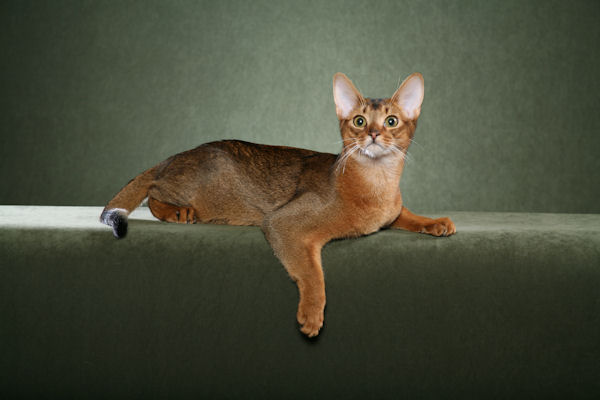

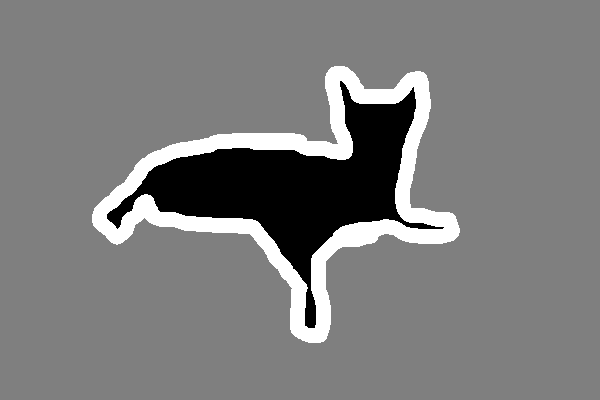

[0 1 2]


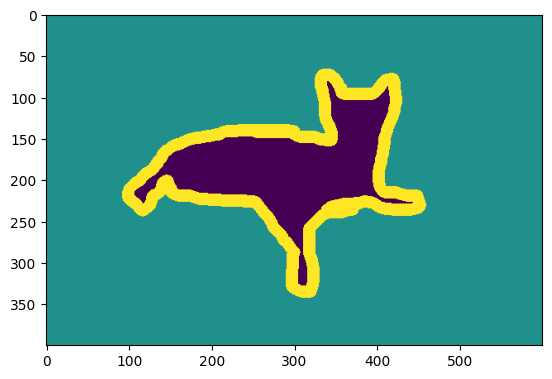

In [5]:
index = 0
display(Image(filename=input_img_paths[index]))

img = ImageOps.autocontrast(PILImage.open(target_img_paths[index]))
display(img)
a = cv2.imread(target_img_paths[index]) - 1
print(np.unique(a))
plt.imshow(a[:, :, 0])
plt.show()

We will now read our images, and build two different sets of data:
1. Training set;
2. Testing set.

The training set will be further divided into training and validation, with a hold-out approach.

In [6]:
x = np.zeros((500, 128, 128, 3), dtype="float32")
y = np.zeros((500, 128, 128, 3), dtype="int32")

print("Loading training images...")
for j in range(0, 500):
    img = cv2.imread(input_img_paths[j])
    img2 = cv2.imread(target_img_paths[j])
    try:
        img = cv2.resize(img, (128, 128))
        img2 = cv2.resize(img2, (128, 128))
        x[j] = img
        y[j] = img2
    except:
        print(f"  Failed to load image {j}")
    if (j + 1) % 100 == 0:
        print(f"  {j + 1}/500 images loaded")
print("Done.")

Loading training images...
  100/500 images loaded
  200/500 images loaded
  300/500 images loaded
  400/500 images loaded
  500/500 images loaded
Done.


In [7]:
x_test = np.zeros((50, 128, 128, 3), dtype="float32")
y_test = np.zeros((50, 128, 128, 3), dtype="int32")

print("Loading test images...")
for j in range(500, 550):
    img = cv2.imread(input_img_paths[j])
    img2 = cv2.imread(target_img_paths[j])
    try:
        img = cv2.resize(img, (128, 128))
        img2 = cv2.resize(img2, (128, 128))
        x_test[j - 500] = img
        y_test[j - 500] = img2
    except:
        print(f"  Failed to load image {j}")
    if (j - 499) % 10 == 0:
        print(f"  {j - 499}/50 images loaded")
print("Done.")

Loading test images...
  10/50 images loaded
  20/50 images loaded
  30/50 images loaded
  40/50 images loaded
  50/50 images loaded
Done.


In [8]:
# Shift trimap values from {1,2,3} to {0,1,2} — PyTorch CrossEntropyLoss
# expects integer class indices directly, no one-hot encoding needed.
y = y[:, :, :, 0] - 1        # shape: (500, 128, 128)
y_test = y_test[:, :, :, 0] - 1  # shape: (50, 128, 128)

**Exercise 1**

Write the code to implement (from scratch) a Unet architecture, and evaluate it on the Oxford-IIIT pet dataset.

* First, build a function `double_conv_block(in_channels, out_channels)` that builds two consecutive Conv2d + ReLU layers.

In [9]:
def double_conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
    )

* Now, define a `DownsampleBlock` that performs one encoder step:
  1. Two convolutional layers (using `double_conv_block`);
  2. Max pooling;
  3. Dropout.

It returns both the feature map (for the skip connection) and the pooled output.

In [10]:
class DownsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = double_conv_block(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        f = self.conv(x)
        p = self.drop(self.pool(f))
        return f, p

It is now the moment of upsample blocks.

* Write an `UpsampleBlock(in_channels, skip_channels, out_channels)` where `skip_channels` is the number of
  channels from the corresponding encoder skip connection.
* Use `ConvTranspose2d` with kernel size 3, stride 2 for upsampling.

In [11]:
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels, out_channels, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        self.drop = nn.Dropout(0.3)
        self.conv = double_conv_block(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = self.drop(torch.cat([x, skip], dim=1))
        return self.conv(x)

Now we build the UNet following the original architecture.

In [12]:
class UNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Encoder
        self.down1 = DownsampleBlock(3, 64)
        self.down2 = DownsampleBlock(64, 128)
        self.down3 = DownsampleBlock(128, 256)
        self.down4 = DownsampleBlock(256, 512)
        # Bottleneck
        self.bottleneck = double_conv_block(512, 1024)
        # Decoder
        self.up6 = UpsampleBlock(1024, 512, 512)
        self.up7 = UpsampleBlock(512, 256, 256)
        self.up8 = UpsampleBlock(256, 128, 128)
        self.up9 = UpsampleBlock(128, 64, 64)
        # Output
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        f1, p1 = self.down1(x)
        f2, p2 = self.down2(p1)
        f3, p3 = self.down3(p2)
        f4, p4 = self.down4(p3)
        bottleneck = self.bottleneck(p4)
        u6 = self.up6(bottleneck, f4)
        u7 = self.up7(u6, f3)
        u8 = self.up8(u7, f2)
        u9 = self.up9(u8, f1)
        return self.out_conv(u9)

Now we instantiate the model, define the Adam optimizer and cross-entropy loss.

Note: `nn.CrossEntropyLoss` in PyTorch expects raw logits (no softmax) and integer class indices as targets,
so there is no need for `to_categorical` or a final softmax layer.

In [13]:
unet_model = UNet(num_classes=3).to(device)

optimizer = torch.optim.Adam(unet_model.parameters())
criterion = nn.CrossEntropyLoss()

print(unet_model)

UNet(
  (down1): DownsampleBlock(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (drop): Dropout(p=0.3, inplace=False)
  )
  (down2): DownsampleBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (drop): Dropout(p=0.3, inplace=False)
  )
  (down3): DownsampleBlock(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256

Finally, we train our model

In [18]:
import time
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Normalise and convert to (N, C, H, W) tensors
x_tensor = torch.from_numpy(x / 255.0).float().permute(0, 3, 1, 2)
y_tensor = torch.from_numpy(y).long()

x_train, x_val, y_train, y_val = train_test_split(
    x_tensor, y_tensor, test_size=0.2, random_state=1
)

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=20, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val,   y_val),   batch_size=20, shuffle=False)

n_train_batches = len(train_loader)
n_val_batches   = len(val_loader)
epochs = 50
best_val_loss = float('inf')

print(f"Training on {len(x_train)} samples, validating on {len(x_val)} samples")
print(f"Batches per epoch: {n_train_batches} train, {n_val_batches} val\n")

for epoch in range(epochs):
    epoch_start = time.time()

    # --- training ---
    unet_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch_idx, (xb, yb) in enumerate(train_loader):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = unet_model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * xb.size(0)
        train_correct += (preds.argmax(dim=1) == yb).sum().item()
        train_total   += yb.numel()
        print(f"  Epoch {epoch+1}/{epochs} | train batch {batch_idx+1}/{n_train_batches} "
              f"| batch loss: {loss.item():.4f}", end="\r")

    # --- validation ---
    unet_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(val_loader):
            xb, yb = xb.to(device), yb.to(device)
            preds = unet_model(xb)
            loss  = criterion(preds, yb)
            val_loss    += loss.item() * xb.size(0)
            val_correct += (preds.argmax(dim=1) == yb).sum().item()
            val_total   += yb.numel()
            print(f"  Epoch {epoch+1}/{epochs} | val batch {batch_idx+1}/{n_val_batches}",
                  end="\r")

    elapsed = time.time() - epoch_start
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(unet_model.state_dict(), 'oxford_segmentation.pth')
        saved_marker = " [saved]"
    else:
        saved_marker = ""

    print(
        f"Epoch {epoch+1}/{epochs}  "
        f"loss: {train_loss/len(x_train):.4f}  acc: {train_correct/train_total:.4f}  "
        f"val_loss: {val_loss/len(x_val):.4f}  val_acc: {val_correct/val_total:.4f}  "
        f"({elapsed:.1f}s){saved_marker}"
    )

Training on 400 samples, validating on 100 samples
Batches per epoch: 20 train, 5 val

Epoch 1/50  loss: 0.5570  acc: 0.7756  val_loss: 0.5481  val_acc: 0.7806  (6.8s) [saved]
Epoch 2/50  loss: 0.5503  acc: 0.7806  val_loss: 0.5485  val_acc: 0.7824  (6.8s)
Epoch 3/50  loss: 0.5416  acc: 0.7831  val_loss: 0.5589  val_acc: 0.7736  (6.9s)
Epoch 4/50  loss: 0.5256  acc: 0.7926  val_loss: 0.5191  val_acc: 0.7959  (7.0s) [saved]
Epoch 5/50  loss: 0.5424  acc: 0.7859  val_loss: 0.5337  val_acc: 0.7902  (7.1s)
Epoch 6/50  loss: 0.5199  acc: 0.7951  val_loss: 0.4909  val_acc: 0.8034  (7.0s) [saved]
Epoch 7/50  loss: 0.4984  acc: 0.8052  val_loss: 0.5076  val_acc: 0.7971  (6.9s)
Epoch 8/50  loss: 0.5027  acc: 0.8020  val_loss: 0.5057  val_acc: 0.8007  (6.8s)
Epoch 9/50  loss: 0.4832  acc: 0.8119  val_loss: 0.4935  val_acc: 0.8052  (6.8s)
Epoch 10/50  loss: 0.4773  acc: 0.8121  val_loss: 0.4832  val_acc: 0.8076  (6.8s) [saved]
Epoch 11/50  loss: 0.4957  acc: 0.8044  val_loss: 0.4726  val_acc: 0.8

Let us visualize a few of our predictions. Try a bunch of images in the test set.

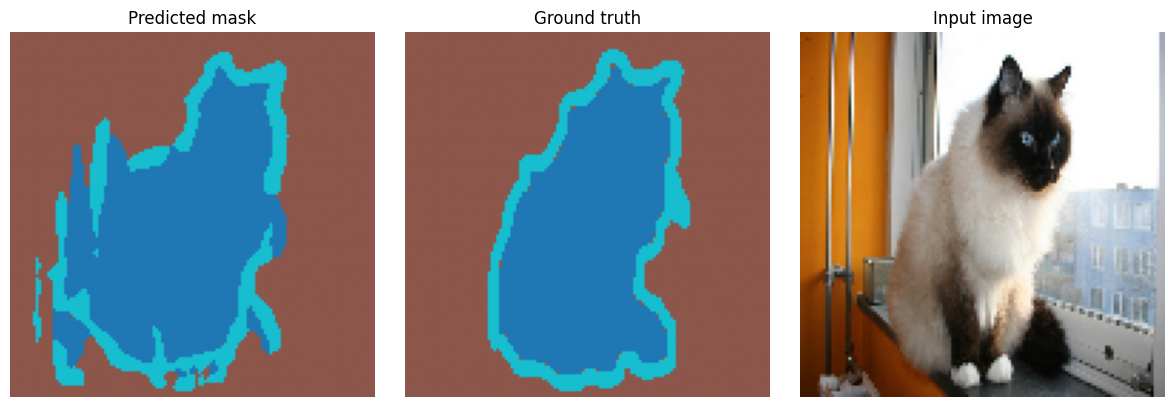

Unique predicted classes: [0 1 2]


In [19]:
x_test_tensor = torch.from_numpy(x_test / 255.0).float().permute(0, 3, 1, 2)
y_test_tensor = torch.from_numpy(y_test).long()

unet_model.eval()
with torch.no_grad():
    val_preds = unet_model(x_test_tensor.to(device)).cpu()

def display_mask(i):
    mask = val_preds[i].argmax(dim=0).numpy()   # (H, W)
    gt   = y_test_tensor[i].numpy()             # (H, W)
    img  = cv2.cvtColor(x_test[i].astype('uint8'), cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(mask, vmin=0, vmax=2, cmap='tab10')
    axes[0].set_title('Predicted mask')
    axes[1].imshow(gt,   vmin=0, vmax=2, cmap='tab10')
    axes[1].set_title('Ground truth')
    axes[2].imshow(img)
    axes[2].set_title('Input image')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    print('Unique predicted classes:', np.unique(mask))

display_mask(0)

**Exercise 2**
Try to change a few parameters in the UNet, e.g.:
- Adjust the Dropout rate in `DownsampleBlock` / `UpsampleBlock`;
- Use more images for training;
- Change the learning rate (pass `lr=...` to `torch.optim.Adam`);
- Change the optimizer (e.g. `torch.optim.SGD`);
- Add batch normalization after each Conv2d.